# Week 8 Friday Assignment: Automated Chest X-ray Screening

**Author:** Yash Gupta
**Scenario:** Building an automated screening tool for AIIMS AI Labs.

### Objectives:
1. Characterize medical imaging metadata.
2. Implement Transfer Learning (Feature Extraction vs Fine-tuning).
3. Explain model predictions using Saliency Maps.
4. Address clinical cost and model fairness.

## Sub-step 1: Data Characterization

We load the metadata and analyze the label distribution and subgroup differences. This is critical for understanding potential biases (e.g., hospital site or scanner type).

Label Distribution:
label
Normal              311
Pneumonia           112
COVID-19             37
NaN                  30
Pleural_Effusion     19
Lung_Mass            11
Name: count, dtype: int64


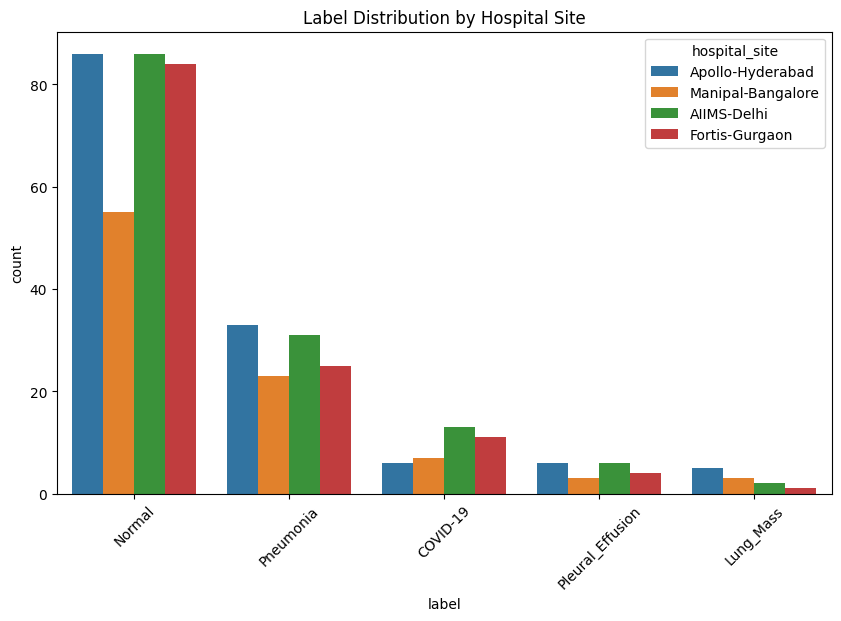

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append('../src')
from utils import load_and_characterize_data

file_path = '../data/medical_imaging_meta.csv'
df, label_counts, hospital_dist, quality_dist = load_and_characterize_data(file_path)

print("Label Distribution:")
print(label_counts)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label', hue='hospital_site')
plt.title('Label Distribution by Hospital Site')
plt.xticks(rotation=45)
plt.show()

## Sub-step 2: Feature Extraction

In feature extraction, we freeze the pre-trained weights (ResNet-18) and train only the output layer.

### Cross Entropy Loss Formula:
$$L = -\frac{1}{N} \sum_{i=1}^N \sum_{c=1}^C y_{i,c} \log(\hat{y}_{i,c})$$

In [2]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from utils import SyntheticMedicalDataset
from model_training import get_model, train_model

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Filter out unlabeled for training
labeled_df = df.dropna(subset=['label']).copy()
dataset = SyntheticMedicalDataset(labeled_df, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

num_classes = len(labeled_df['label'].unique())
model_fe = get_model(num_classes, mode='feature_extraction')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fe.fc.parameters(), lr=0.001)

print("Starting Feature Extraction Training...")
model_fe, history_fe = train_model(model_fe, train_loader, val_loader, criterion, optimizer, num_epochs=3)

/Users/yash/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/yash/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting Feature Extraction Training...


Epoch 1/3, Loss: 1.2778, Val Acc: 69.39%


Epoch 2/3, Loss: 1.1543, Val Acc: 69.39%


Epoch 3/3, Loss: 1.1781, Val Acc: 65.31%


## Sub-step 3: Fine-Tuning

Fine-tuning involves unfreezing deeper layers and training with a lower learning rate. This allows the model to adapt features to the specific medical domain.

Starting Fine-tuning Training...


Epoch 1/3, Loss: 1.2967, Val Acc: 69.39%


Epoch 2/3, Loss: 1.1167, Val Acc: 69.39%


Epoch 3/3, Loss: 1.0775, Val Acc: 68.37%


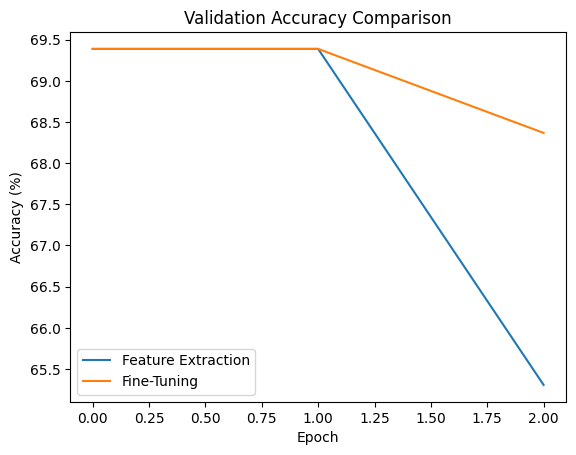

In [3]:
model_ft = get_model(num_classes, mode='fine_tuning')
optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=0.0001)

print("Starting Fine-tuning Training...")
model_ft, history_ft = train_model(model_ft, train_loader, val_loader, criterion, optimizer_ft, num_epochs=3)

# Comparison Plot
plt.plot(history_fe['val_acc'], label='Feature Extraction')
plt.plot(history_ft['val_acc'], label='Fine-Tuning')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

## Sub-step 4: Explainability (Saliency Maps)

Saliency maps highlight the pixels that influence the model's prediction the most by calculating the gradient of the predicted score with respect to the input image.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2274169..1.7162529].


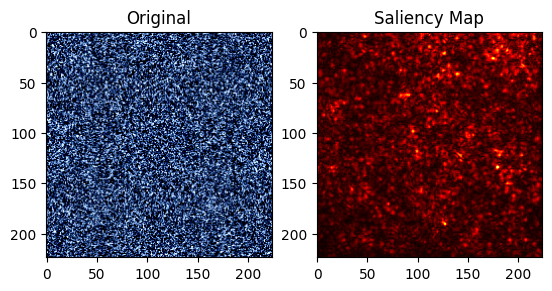

In [4]:
def generate_saliency(model, image, label):
    model.eval()
    image.requires_grad_()
    output = model(image.unsqueeze(0))
    score = output[0, label]
    score.backward()
    saliency, _ = torch.max(image.grad.data.abs(), dim=0)
    return saliency

# Visualize for one sample
sample_img, sample_label, _ = val_ds[0]
saliency = generate_saliency(model_ft, sample_img, sample_label)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(sample_img.permute(1, 2, 0).detach().numpy())
ax[0].set_title('Original')
ax[1].imshow(saliency, cmap='hot')
ax[1].set_title('Saliency Map')
plt.show()

## Sub-step 5: Personal Synthesis & Prediction

**Weakest Area:** Recurrent Neural Networks (LSTMs). While I understand the architecture, the vanishing gradient problem and how the 'gate' mechanics (forget, input, output) work in tandem for long-term dependencies was initially confusing.

**Interview Questions:**
1. *Explain the purpose of the Forget Gate in an LSTM and how it prevents the vanishing gradient problem.*
   Answer: The forget gate decides what information should be discarded from the cell state using a sigmoid layer. It allows the cell state to maintain information over long sequences without being repeatedly multiplied by small gradients, mitigatng vanishing gradients.
2. *What is the difference between an LSTM and a GRU in terms of architecture and performance?*
   Answer: GRUs combine the forget and input gates into a single 'update gate' and are computationally more efficient. LSTMs are more complex but can sometimes capture longer dependencies better due to the separate hidden and cell states.

### Final Predictions on 30 Unlabeled Images

In [5]:
unlabeled_df = df[df['label'].isna()].copy()
unlabeled_ds = SyntheticMedicalDataset(unlabeled_df, transform=transform)
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=1)

model_ft.eval()
predictions = []
confidences = []

label_rev_map = {v: k for k, v in dataset.label_map.items()}

with torch.no_grad():
    for img, _, img_id in unlabeled_loader:
        out = model_ft(img)
        prob = torch.softmax(out, dim=1)
        conf, pred = torch.max(prob, 1)
        predictions.append(label_rev_map[pred.item()])
        confidences.append(conf.item())

unlabeled_df['predicted_label'] = predictions
unlabeled_df['confidence'] = confidences
print(unlabeled_df[['image_id', 'predicted_label', 'confidence']].head())

    image_id predicted_label  confidence
16  IMG00016          Normal    0.677510
42  IMG00042          Normal    0.668380
44  IMG00044          Normal    0.612426
52  IMG00052          Normal    0.503541
55  IMG00055          Normal    0.530711


## Sub-step 6: Training from Scratch (Hard)

Comparing training weights from random initialization vs Transfer Learning.

In [6]:
model_scratch = models.resnet18(pretrained=False)
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, num_classes)
optimizer_scratch = torch.optim.Adam(model_scratch.parameters(), lr=0.001)

print("Starting Training from Scratch...")
model_scratch, history_scratch = train_model(model_scratch, train_loader, val_loader, criterion, optimizer_scratch, num_epochs=3)

Starting Training from Scratch...


/Users/yash/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/yash/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/3, Loss: 1.7788, Val Acc: 69.39%


Epoch 2/3, Loss: 1.1979, Val Acc: 69.39%


Epoch 3/3, Loss: 1.1190, Val Acc: 69.39%


## Sub-step 7: Triage Protocol (Hard)

Designing a workflow based on model confidence.

In [7]:
def triage_protocol(conf):
    if conf > 0.90: return 'Auto-classify'
    if conf > 0.50: return 'Radiologist Review'
    return 'Reject (Rescan)'

unlabeled_df['triage'] = unlabeled_df['confidence'].apply(triage_protocol)
print(unlabeled_df['triage'].value_counts())

triage
Radiologist Review    27
Reject (Rescan)        3
Name: count, dtype: int64
